In [53]:
import pandas as pd
import matplotlib.pyplot as plt


In [43]:

df = pd.read_csv("C:\\Users\\Geraldine\\Downloads\\aldimi_demanda_alimentos_real.csv")

In [44]:
df.head()

,id,semana,trimestre,centro_id,codigo_ciudad,codigo_region,tipo_centro,area_operativa_km2,alimento_id,categoria_alimento,...,hay_descuento,promocion_email,destacado_inicio,demanda_semana_anterior,demanda_promedio_4sem,demanda_promedio_global,costo_total_semana,pedidos_semana,alerta_demanda_alta,alerta_demanda_baja
0,1436842,1,1,10,590,56,TYPE_B,6.3,1062,Beverages,...,0,0,0,NaN,NaN,423.2,156902.35,865,1,0
1,1205013,2,1,10,590,56,TYPE_B,6.3,1062,Beverages,...,0,0,0,865.0,865.0,423.2,143387.52,782,1,0
2,1447751,3,1,10,590,56,TYPE_B,6.3,1062,Beverages,...,0,0,0,782.0,823.5,423.2,156890.36,851,1,0
3,1014968,4,1,10,590,56,TYPE_B,6.3,1062,Beverages,...,1,0,0,851.0,832.7,423.2,219196.72,1202,1,0
4,1003563,5,1,10,590,56,TYPE_B,6.3,1062,Beverages,...,0,0,0,1202.0,925.0,423.2,175687.62,958,1,0


In [45]:
df.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 456548 entries, 0 to 456547
Data columns (total 24 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       456548 non-null  int64  
 1   semana                   456548 non-null  int64  
 2   trimestre                456548 non-null  int64  
 3   centro_id                456548 non-null  int64  
 4   codigo_ciudad            456548 non-null  int64  
 5   codigo_region            456548 non-null  int64  
 6   tipo_centro              456548 non-null  object 
 7   area_operativa_km2       456548 non-null  float64
 8   alimento_id              456548 non-null  int64  
 9   categoria_alimento       456548 non-null  object 
 10  tipo_cocina              456548 non-null  object 
 11  precio_base              456548 non-null  float64
 12  precio_venta             456548 non-null  float64
 13  descuento_pct            456548 non-null  float64
 14  hay_

In [46]:
df.isnull().sum()


id                            0
semana                        0
trimestre                     0
centro_id                     0
codigo_ciudad                 0
codigo_region                 0
tipo_centro                   0
area_operativa_km2            0
alimento_id                   0
categoria_alimento            0
tipo_cocina                   0
precio_base                   0
precio_venta                  0
descuento_pct                 0
hay_descuento                 0
promocion_email               0
destacado_inicio              0
demanda_semana_anterior    3597
demanda_promedio_4sem      3597
demanda_promedio_global       0
costo_total_semana            0
pedidos_semana                0
alerta_demanda_alta           0
alerta_demanda_baja           0
dtype: int64

In [47]:
(df.isnull().sum() / len(df)) * 100


id                         0.000000
semana                     0.000000
trimestre                  0.000000
centro_id                  0.000000
codigo_ciudad              0.000000
codigo_region              0.000000
tipo_centro                0.000000
area_operativa_km2         0.000000
alimento_id                0.000000
categoria_alimento         0.000000
tipo_cocina                0.000000
precio_base                0.000000
precio_venta               0.000000
descuento_pct              0.000000
hay_descuento              0.000000
promocion_email            0.000000
destacado_inicio           0.000000
demanda_semana_anterior    0.787869
demanda_promedio_4sem      0.787869
demanda_promedio_global    0.000000
costo_total_semana         0.000000
pedidos_semana             0.000000
alerta_demanda_alta        0.000000
alerta_demanda_baja        0.000000
dtype: float64

In [48]:
df = df.dropna()



In [49]:
df.isnull().sum()

id                         0
semana                     0
trimestre                  0
centro_id                  0
codigo_ciudad              0
codigo_region              0
tipo_centro                0
area_operativa_km2         0
alimento_id                0
categoria_alimento         0
tipo_cocina                0
precio_base                0
precio_venta               0
descuento_pct              0
hay_descuento              0
promocion_email            0
destacado_inicio           0
demanda_semana_anterior    0
demanda_promedio_4sem      0
demanda_promedio_global    0
costo_total_semana         0
pedidos_semana             0
alerta_demanda_alta        0
alerta_demanda_baja        0
dtype: int64

In [50]:
df.duplicated().sum()


0

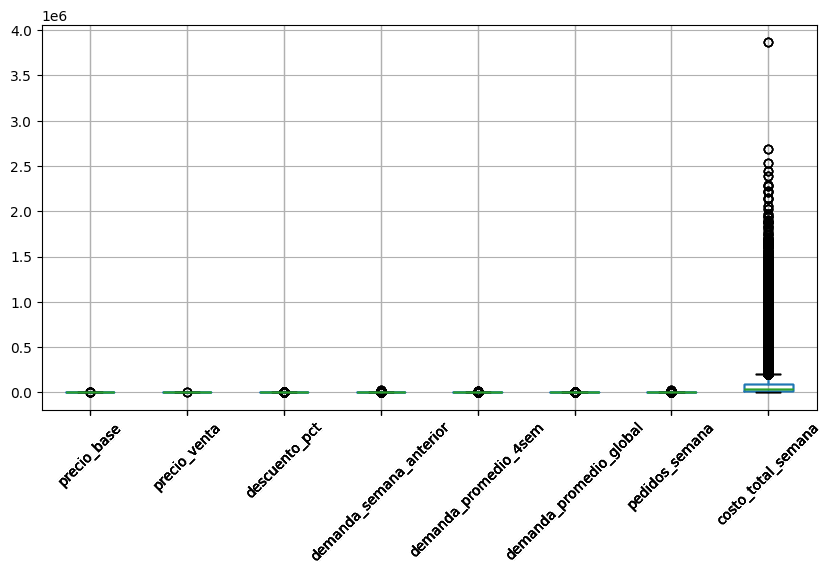

In [55]:
cols = [
    "precio_base", "precio_venta", "descuento_pct",
    "demanda_semana_anterior", "demanda_promedio_4sem",
    "demanda_promedio_global", "pedidos_semana", "costo_total_semana"
]

df[cols].boxplot(rot=45, figsize=(10,5))
plt.show()


In [22]:
for col in cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    outliers = df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)]
    print(col, len(outliers))


precio_base 8
precio_venta 1
descuento_pct 81071
demanda_semana_anterior 32810
demanda_promedio_4sem 31715
demanda_promedio_global 11061
pedidos_semana 32703
costo_total_semana 29684


In [56]:
(df["descuento_pct"] < 0).sum()


115203

In [57]:
df[df["descuento_pct"] < 0]


,id,semana,trimestre,centro_id,codigo_ciudad,codigo_region,tipo_centro,area_operativa_km2,alimento_id,categoria_alimento,...,hay_descuento,promocion_email,destacado_inicio,demanda_semana_anterior,demanda_promedio_4sem,demanda_promedio_global,costo_total_semana,pedidos_semana,alerta_demanda_alta,alerta_demanda_baja
1,1205013,2,1,10,590,56,TYPE_B,6.3,1062,Beverages,...,0,0,0,865.0,865.0,423.2,143387.52,782,1,0
2,1447751,3,1,10,590,56,TYPE_B,6.3,1062,Beverages,...,0,0,0,782.0,823.5,423.2,156890.36,851,1,0
4,1003563,5,1,10,590,56,TYPE_B,6.3,1062,Beverages,...,0,0,0,1202.0,925.0,423.2,175687.62,958,1,0
15,1276418,16,2,10,590,56,TYPE_B,6.3,1062,Beverages,...,0,0,0,770.0,941.8,423.2,122873.79,663,1,0
24,1194634,25,2,10,590,56,TYPE_B,6.3,1062,Beverages,...,0,0,0,998.0,1319.5,423.2,178042.56,971,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
456537,1071894,103,4,186,649,34,TYPE_A,3.4,2956,Fish,...,0,0,0,13.0,26.8,92.5,23281.20,40,0,1
456542,1052219,111,4,186,649,34,TYPE_A,3.4,2956,Fish,...,0,0,0,54.0,51.0,92.5,32066.65,55,0,0
456543,1255251,112,4,186,649,34,TYPE_A,3.4,2956,Fish,...,0,0,0,55.0,51.5,92.5,47808.46,82,0,0
456544,1436164,113,4,186,649,34,TYPE_A,3.4,2956,Fish,...,0,0,0,82.0,58.2,92.5,23321.20,40,0,1


In [58]:
df["recargo_pct"] = df["descuento_pct"].apply(lambda x: abs(x) if x < 0 else 0)
df["descuento_pct"] = df["descuento_pct"].apply(lambda x: x if x > 0 else 0)



In [62]:
df[df["recargo_pct"] > 0]["recargo_pct"].unique()


array([ 0.55,  1.1 ,  1.09, ..., 20.2 , 24.98,  8.91])

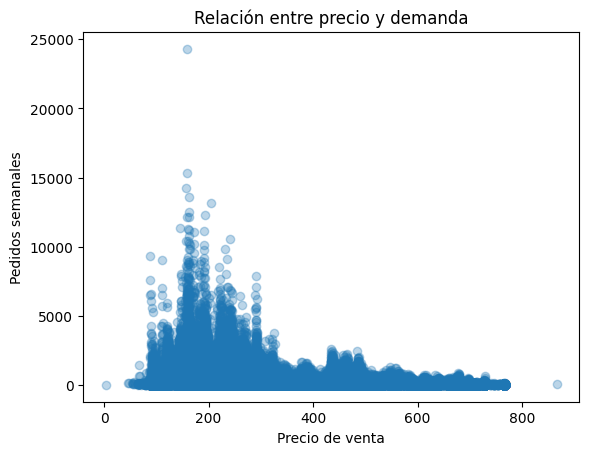

In [64]:
plt.scatter(df["precio_venta"], df["pedidos_semana"], alpha=0.3)
plt.xlabel("Precio de venta")
plt.ylabel("Pedidos semanales")
plt.title("Relación entre precio y demanda")
plt.show()


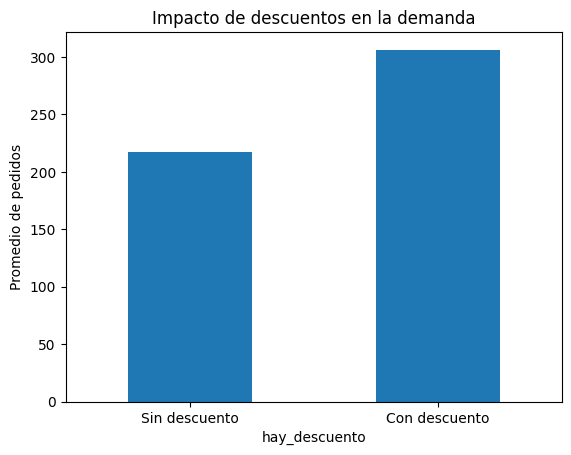

In [29]:
df.groupby("hay_descuento")["pedidos_semana"].mean().plot(kind="bar")
plt.xticks([0,1], ["Sin descuento", "Con descuento"], rotation=0)
plt.title("Impacto de descuentos en la demanda")
plt.ylabel("Promedio de pedidos")
plt.show()


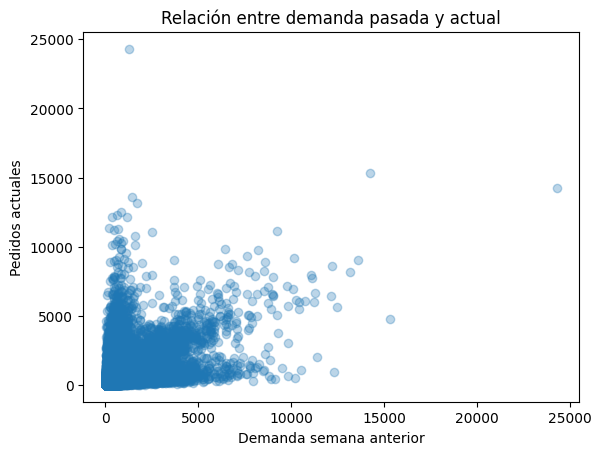

In [30]:
plt.scatter(df["demanda_semana_anterior"], df["pedidos_semana"], alpha=0.3)
plt.xlabel("Demanda semana anterior")
plt.ylabel("Pedidos actuales")
plt.title("Relación entre demanda pasada y actual")
plt.show()


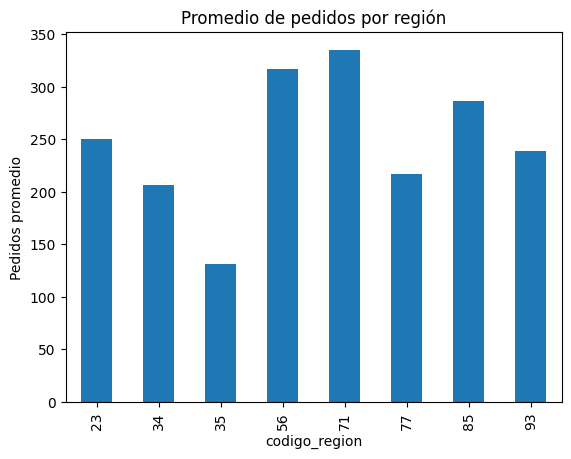

In [31]:
df.groupby("codigo_region")["pedidos_semana"].mean().plot(kind="bar")
plt.title("Promedio de pedidos por región")
plt.ylabel("Pedidos promedio")
plt.show()


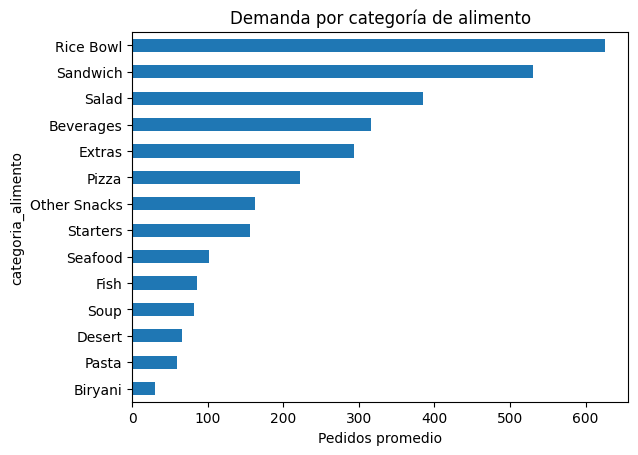

In [32]:
df.groupby("categoria_alimento")["pedidos_semana"].mean().sort_values().plot(kind="barh")
plt.title("Demanda por categoría de alimento")
plt.xlabel("Pedidos promedio")
plt.show()


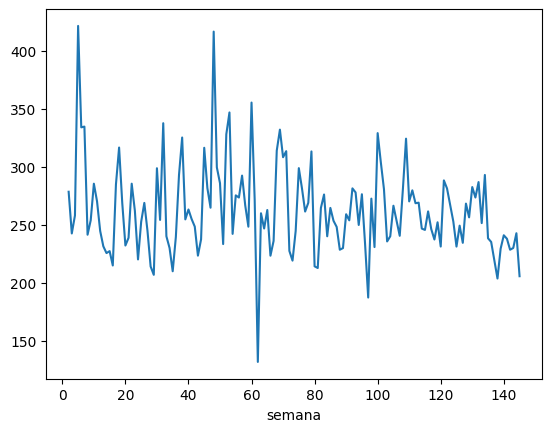

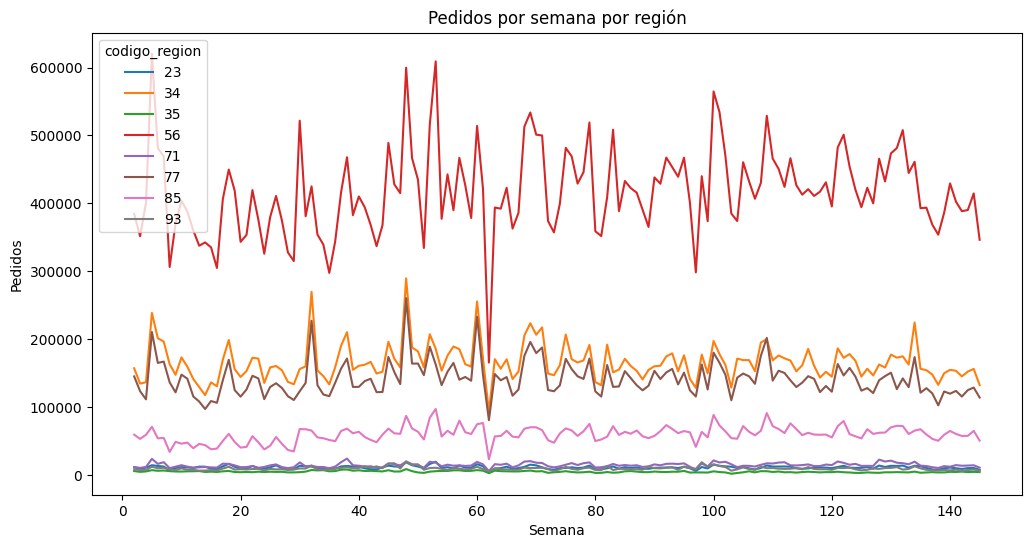

In [36]:
df.groupby(["semana", "codigo_region"])["pedidos_semana"].sum().unstack().plot(figsize=(12,6))

plt.title("Pedidos por semana por región")
plt.xlabel("Semana")
plt.ylabel("Pedidos")
plt.show()




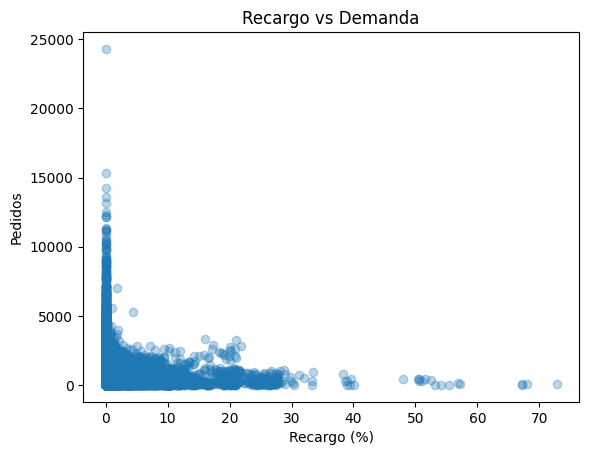

In [65]:
import matplotlib.pyplot as plt

plt.scatter(df["recargo_pct"], df["pedidos_semana"], alpha=0.3)
plt.xlabel("Recargo (%)")
plt.ylabel("Pedidos")
plt.title("Recargo vs Demanda")
plt.show()
